# Bonos cuponados

La idea es entender la lógica financiera detrás de un bono cuponado:

- cómo se calcula su precio,
- cómo se separa cada cupón entre interés y amortización,
- cómo evoluciona el valor en libros del bono,
- qué ocurre cuando el bono se vende con prima o descuento,
- y cómo se comporta el valor teórico entre fechas de cupón.

## Librerias 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## ¿Qué es un bono cuponado?

Un bono es un instrumento de deuda. Quien compra el bono está prestando dinero y, a cambio, recibe pagos periódicos llamados cupones.

Al vencimiento, además de los cupones, el emisor paga el valor nominal o valor de redención.

Usaremos la siguiente notación:

- $C$: valor de redención o valor nominal del bono.
- $F$: valor facial usado para calcular el cupón.
- $r$: tasa cupón por periodo.
- $j$: tasa de rendimiento o tasa de mercado por periodo.
- $n$: número total de cupones.
- $v$: factor de descuento, definido como:

$$
v = \frac{1}{1+j}
$$

El cupón periódico es:

$$
Fr
$$

Si la tasa cupón es mayor que la tasa de mercado, el bono se vende con prima.

Si la tasa cupón es menor que la tasa de mercado, el bono se vende con descuento.

Si ambas tasas son iguales, el bono se vende a la par.

## Factor de valor presente de una anualidad

Como el bono paga cupones periódicos, necesitamos valorar una anualidad.

El valor presente de una anualidad vencida de $1$ durante $n$ periodos a tasa $j$ es:

$$
a_{\overline{n}|j} = \frac{1 - (1+j)^{-n}}{j}
$$

Este factor nos dice cuánto vale hoy una serie de pagos iguales de $1$ en cada periodo.

En bonos, este factor se usa para traer a valor presente los cupones.

In [2]:
def an_j(n, j):
    """
    Factor de valor presente de una anualidad vencida.
    """
    return (1 - (1 + j)**(-n)) / j

## Precio de un bono cuponado

El precio de un bono se puede calcular como el valor presente de:

1. todos los cupones futuros,
2. más el valor de redención al vencimiento.

La forma clásica es:

$$
P = Fr a_{\overline{n}|j} + C v^n
$$

Sin embargo, en el material se usa una forma equivalente:

$$
P = C + (Fr - Cj)a_{\overline{n}|j}
$$

Esta fórmula es muy útil porque muestra directamente si el bono se vende con prima o descuento.

El término clave es:

$$
Fr - Cj
$$

Si:

$$
Fr > Cj
$$

entonces el cupón es mayor que el interés requerido por el mercado y el bono vale más que $C$.

Si:

$$
Fr < Cj
$$

entonces el cupón es menor que el interés requerido por el mercado y el bono vale menos que $C$.

In [3]:
def precio_bono(C, F, r, j, n):
    """
    Precio de un bono cuponado usando la fórmula:
    P = C + (Fr - Cj) * a_n_j
    """
    return C + (F*r - C*j) * an_j(n, j)

## Schedule de amortización del bono

Aunque un bono tradicional no amortiza capital físicamente en cada cupón, desde el punto de vista contable o actuarial se puede construir una tabla de valor en libros.

La idea es separar cada cupón en dos partes:

1. interés ganado sobre el valor en libros,
2. amortización de la prima o acumulación del descuento.

En el material se usan las siguientes fórmulas:

### Interés del periodo

$$
I_k = Fr - (Fr - Cj)v^{n-k+1}
$$

### Capital o amortización

$$
P_k = (Fr - Cj)v^{n-k+1}
$$

### Saldo insoluto o valor en libros después del periodo $k$

$$
OB_k = C + (Fr - Cj)a_{\overline{n-k}|j}
$$

Donde $OB_k$ representa el valor en libros del bono después del pago del cupón en el periodo $k$.

In [15]:
def tabla_amortizacion_bono(C, F, r, j, n, incluir_periodo_0=True):
    v = (1 + j)**(-1)
    
    periodos = np.arange(1, n + 1)
    
    cupon = F * r
    interes = F*r - (F*r - C*j) * v**(n - periodos + 1)
    capital = (F*r - C*j) * v**(n - periodos + 1)
    insoluto = C + (F*r - C*j) * np.array([an_j(n - k, j) for k in periodos])
    
    tabla = pd.DataFrame({
        "PERIODO": periodos,
        "CUPON": cupon,
        "INTERES": interes,
        "CAPITAL": capital,
        "INSOLUTO": insoluto
    })
    
    if incluir_periodo_0:
        P = precio_bono(C, F, r, j, n)
        fila_0 = pd.DataFrame({
            "PERIODO": [0],
            "CUPON": [np.nan],
            "INTERES": [np.nan],
            "CAPITAL": [np.nan],
            "INSOLUTO": [P]
        })
        tabla = pd.concat([fila_0, tabla], ignore_index=True)
    
    return tabla

### Ejemplo 1: bono con prima

Consideremos un bono con:

- $C = 100$
- $F = 100$
- $r = 0.045$
- $j = 0.04$
- $n = 20$

Aquí la tasa cupón es mayor que la tasa de mercado:

$$
4.5\% > 4\%
$$

Por lo tanto, esperamos que el bono tenga un precio mayor que su valor nominal.

In [5]:
C = 100
F = 100
r = 0.045
j = 0.04
n = 20

P = precio_bono(C, F, r, j, n)
print(f"El precio del bono es: {P:.2f}")

El precio del bono es: 106.80


El precio obtenido es aproximadamente:

$$
P \approx 106.7952
$$

Esto significa que el bono se vende con prima.

La prima es:

$$
P - C
$$

En este caso:

$$
106.7952 - 100 = 6.7952
$$

Financieramente, esto ocurre porque el bono paga cupones de $4.5$, pero el mercado solamente exige $4$ por cada $100$ de valor nominal. Ese exceso de cupón hace que el inversionista esté dispuesto a pagar más que $100$.

In [6]:
prima = P - C
print(f"La prima del bono es: {prima:.2f}")

La prima del bono es: 6.80


In [9]:
tabla = tabla_amortizacion_bono(C, F, r, j, n)
tabla.head(10)

,PERIODO,CUPON,INTERES,CAPITAL,INSOLUTO
0,0,NaN,NaN,NaN,106.795163
1,1,4.5,4.271807,0.228193,106.566970
2,2,4.5,4.262679,0.237321,106.329648
3,3,4.5,4.253186,0.246814,106.082834
4,4,4.5,4.243313,0.256687,105.826148
5,5,4.5,4.233046,0.266954,105.559194
6,6,4.5,4.222368,0.277632,105.281561
7,7,4.5,4.211262,0.288738,104.992824
8,8,4.5,4.199713,0.300287,104.692537
9,9,4.5,4.187701,0.312299,104.380238


En este ejemplo, el bono se vende con prima porque el cupón es mayor que la tasa de mercado.

Eso significa que el valor en libros comienza por encima de $100$ y poco a poco baja hasta llegar al valor nominal al vencimiento.

Financieramente, esto se interpreta así:

- El inversionista pagó más de $100$ por el bono.
- Recibe cupones altos en comparación con la tasa de mercado.
- Parte de esos cupones representa interés.
- La otra parte representa la amortización gradual de la prima.
- Al vencimiento, el valor en libros llega a $100$.

Por eso el saldo insoluto disminuye periodo a periodo.

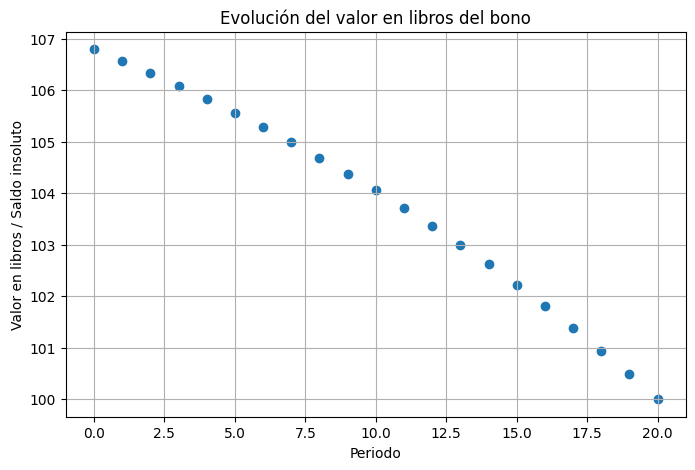

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(tabla["PERIODO"], tabla["INSOLUTO"])
plt.xlabel("Periodo")
plt.ylabel("Valor en libros / Saldo insoluto")
plt.title("Evolución del valor en libros del bono")
plt.grid(True)
plt.show()

## Ejemplo 2: bono con descuento

Ahora consideremos un bono con:

- $C = 1000$
- $F = 1000$
- $r = 0.05$
- $j = 0.08$
- $n = 20$

Aquí la tasa cupón es menor que la tasa de mercado:

$$
5\% < 8\%
$$

Por lo tanto, el bono debe venderse con descuento.

Es decir, su precio será menor que el valor nominal.

In [11]:
C = 1000
F = 1000
r = 0.05
j = 0.08
n = 20

P = precio_bono(C, F, r, j, n)
P

705.4555777765212

El precio es aproximadamente:

$$
P \approx 705.4556
$$

El bono se vende por debajo de $1000$ porque paga un cupón de $50$, pero el mercado exige un rendimiento de $80$ por cada $1000$ de valor nominal.

Como el cupón no compensa completamente la tasa requerida, el inversionista solo aceptaría comprar el bono pagando menos que su valor nominal.

In [13]:
tabla_descuento = tabla_amortizacion_bono(C, F, r, j, n)
tabla_descuento.head(10)

,PERIODO,CUPON,INTERES,CAPITAL,INSOLUTO
0,0,NaN,NaN,NaN,705.455578
1,1,50.0,56.436446,-6.436446,711.892024
2,2,50.0,56.951362,-6.951362,718.843386
3,3,50.0,57.507471,-7.507471,726.350857
4,4,50.0,58.108069,-8.108069,734.458925
5,5,50.0,58.756714,-8.756714,743.215639
6,6,50.0,59.457251,-9.457251,752.672891
7,7,50.0,60.213831,-10.213831,762.886722
8,8,50.0,61.030938,-11.030938,773.917659
9,9,50.0,61.913413,-11.913413,785.831072


En el caso del bono con descuento, el valor en libros comienza por debajo de $1000$ y va aumentando hasta llegar al valor nominal.

Esto ocurre porque:

- el inversionista compra barato,
- recibe cupones relativamente bajos,
- pero al vencimiento recibe $1000$,
- entonces la diferencia entre el precio de compra y el valor nominal funciona como parte del rendimiento.

Por eso, en la tabla, el capital puede aparecer con signo negativo: no estamos amortizando una prima, sino acumulando el descuento.

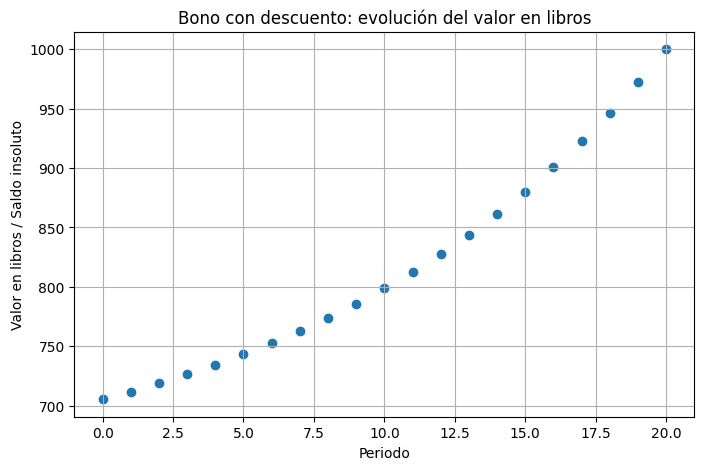

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(tabla_descuento["PERIODO"], tabla_descuento["INSOLUTO"])
plt.xlabel("Periodo")
plt.ylabel("Valor en libros / Saldo insoluto")
plt.title("Bono con descuento: evolución del valor en libros")
plt.grid(True)
plt.show()

## Ejemplo 3: bono con prima

Ahora tomemos:

- $C = 1000$
- $F = 1000$
- $r = 0.05$
- $j = 0.04$
- $n = 20$

Aquí la tasa cupón es mayor que la tasa de mercado:

$$
5\% > 4\%
$$

Por lo tanto, el bono se vende con prima.

In [ ]:
C = 1000
F = 1000
r = 0.05
j = 0.04
n = 20

P = precio_bono(C, F, r, j, n)
print(f"El precio del bono es: {P:.2f}")

1135.903263449677

In [18]:
tabla_prima = tabla_amortizacion_bono(C, F, r, j, n)
tabla_prima.head(10)

,PERIODO,CUPON,INTERES,CAPITAL,INSOLUTO
0,0,NaN,NaN,NaN,1135.903263
1,1,50.0,45.436131,4.563869,1131.339394
2,2,50.0,45.253576,4.746424,1126.592970
3,3,50.0,45.063719,4.936281,1121.656689
4,4,50.0,44.866268,5.133732,1116.522956
5,5,50.0,44.660918,5.339082,1111.183874
6,6,50.0,44.447355,5.552645,1105.631229
7,7,50.0,44.225249,5.774751,1099.856478
8,8,50.0,43.994259,6.005741,1093.850738
9,9,50.0,43.754030,6.245970,1087.604767


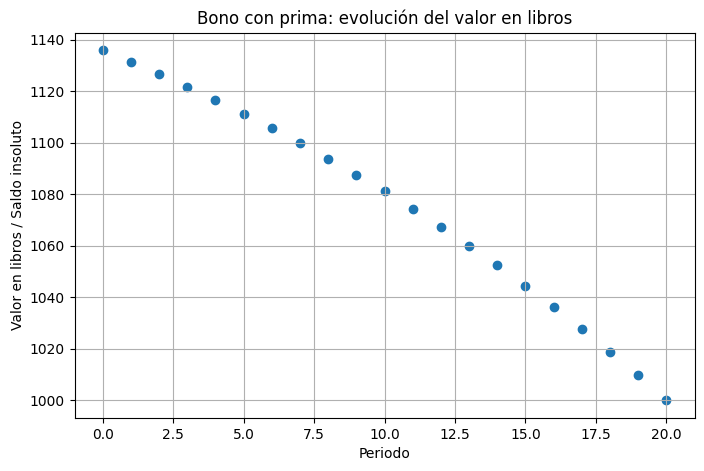

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(tabla_prima["PERIODO"], tabla_prima["INSOLUTO"])
plt.xlabel("Periodo")
plt.ylabel("Valor en libros / Saldo insoluto")
plt.title("Bono con prima: evolución del valor en libros")
plt.grid(True)
plt.show()

## Valor del bono entre fechas de cupón

Hasta ahora solo hemos observado el valor del bono justo después de cada pago de cupón.

Pero entre dos fechas de cupón, el valor teórico del bono no se mantiene constante. Va creciendo con la tasa de rendimiento del mercado.

Si estamos entre el periodo $k$ y $k+1$, el valor teórico se calcula como:

$$
V(t) = OB_k(1+j)^{t-k}
$$

donde:

- $OB_k$ es el valor en libros justo después del cupón en el periodo $k$,
- $t$ es el tiempo fraccionario,
- $t-k$ es el lapso transcurrido desde el último cupón.

Esto genera una trayectoria tipo “diente de sierra”:

- entre cupones, el valor sube por acumulación de intereses,
- en la fecha de cupón, el valor cae porque se paga el cupón,
- después vuelve a acumularse hasta el siguiente cupón.

In [22]:
def valores_teoricos_entre_cupones(tabla, j, n, paso=0.1):
    tiempos = np.round(np.arange(0, n + paso, paso), 10)
    
    df = pd.DataFrame({"TIEMPO": tiempos})
    
    tabla_insoluto = tabla[["PERIODO", "INSOLUTO"]].copy()
    tabla_insoluto = tabla_insoluto.rename(columns={"PERIODO": "TIEMPO"})
    tabla_insoluto["TIEMPO"] = tabla_insoluto["TIEMPO"].astype(float)
    
    df = df.merge(tabla_insoluto, on="TIEMPO", how="left")
    
    valores_teoricos = []
    
    for t in df["TIEMPO"]:
        k = np.floor(t)
        lapso = t - k
        
        OB_k = tabla.loc[tabla["PERIODO"] == k, "INSOLUTO"].values[0]
        valor_t = OB_k * (1 + j)**lapso
        
        valores_teoricos.append(valor_t)
    
    df["TEORICO"] = valores_teoricos
    
    return df

In [23]:
df_teorico = valores_teoricos_entre_cupones(tabla_prima, j=0.04, n=20, paso=0.1)
df_teorico.head(25)

,TIEMPO,INSOLUTO,TEORICO
0,0.0,1135.903263,1135.903263
1,0.1,NaN,1140.367105
2,0.2,NaN,1144.848489
3,0.3,NaN,1149.347483
4,0.4,NaN,1153.864157
5,0.5,NaN,1158.398581
6,0.6,NaN,1162.950824
7,0.7,NaN,1167.520957
8,0.8,NaN,1172.109049
9,0.9,NaN,1176.715171


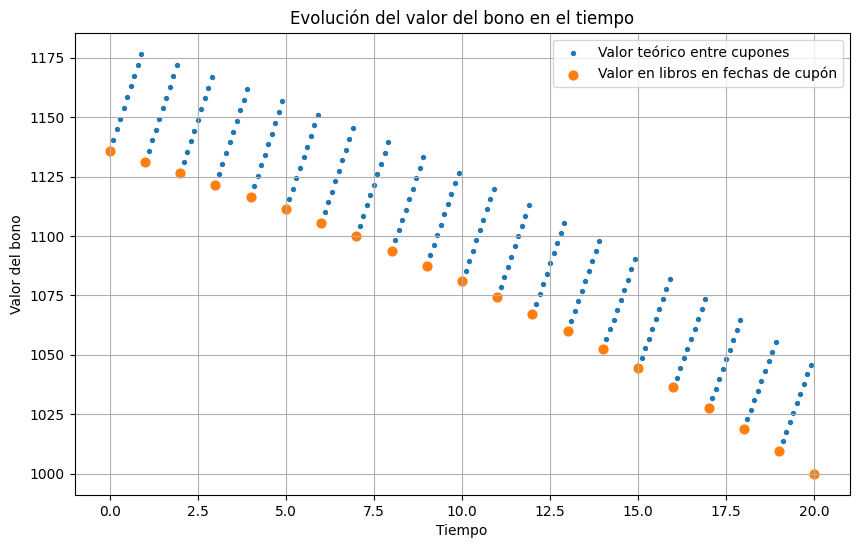

In [24]:
plt.figure(figsize=(10, 6))

plt.scatter(df_teorico["TIEMPO"], df_teorico["TEORICO"], s=8, label="Valor teórico entre cupones")
plt.scatter(df_teorico["TIEMPO"], df_teorico["INSOLUTO"], s=40, label="Valor en libros en fechas de cupón")

plt.xlabel("Tiempo")
plt.ylabel("Valor del bono")
plt.title("Evolución del valor del bono en el tiempo")
plt.grid(True)
plt.legend()
plt.show()

La gráfica permite ver una diferencia importante:

- Los puntos del valor en libros solo existen en fechas de cupón.
- El valor teórico entre cupones crece con la tasa de mercado.
- En cada fecha de cupón hay un salto hacia abajo porque el inversionista recibe el cupón.

Por eso no conviene unir directamente los puntos del valor en libros como si fuera una línea continua.

Financieramente, el bono tiene una evolución discontinua en las fechas de pago.

## Conversión de tasas

En bonos es muy importante cuidar la periodicidad de las tasas.

Por ejemplo, una tasa nominal anual convertible semestralmente no es igual a una tasa efectiva anual.

Si tenemos una tasa nominal anual $i^{(m)}$ convertible $m$ veces al año, la tasa efectiva anual equivalente es:

$$
i = \left(1 + \frac{i^{(m)}}{m}\right)^m - 1
$$

Y si queremos pasar de una tasa efectiva anual a una tasa nominal convertible $m$ veces, usamos:

$$
i^{(m)} = m\left[(1+i)^{1/m} - 1\right]
$$

Esta conversión es clave porque el cupón y la tasa de rendimiento deben estar expresados en la misma periodicidad.

In [25]:
def nominal_a_efectiva(tasa_nominal, m):
    return (1 + tasa_nominal / m)**m - 1

def efectiva_a_nominal(tasa_efectiva, m):
    return m * ((1 + tasa_efectiva)**(1/m) - 1)

In [26]:
tasa_nominal = 0.05
m = 2

tasa_efectiva = nominal_a_efectiva(tasa_nominal, m)
tasa_efectiva

0.05062499999999992

In [27]:
efectiva_a_nominal(tasa_efectiva, m)

0.04999999999999982

## Caso con cupones semestrales

Si un bono paga cupones semestrales, no podemos usar directamente las tasas anuales como si fueran tasas por periodo.

Por ejemplo, si:

- tasa cupón anual: $4.5\%$
- tasa de mercado nominal anual convertible semestralmente: $4\%$
- cupones semestrales

Entonces usamos:

$$
r = \frac{0.045}{2}
$$

y

$$
j = \frac{0.04}{2}
$$

Si hay 20 periodos semestrales, entonces el bono tiene 10 años de vida.

In [28]:
C = 100
F = 100
r = 0.045 / 2
j = 0.04 / 2
n = 20

P_semestral = precio_bono(C, F, r, j, n)
P_semestral

104.08785833614928

El precio aproximado es:

$$
P \approx 104.0879
$$

Este precio sigue siendo mayor que $100$, porque la tasa cupón por periodo sigue siendo mayor que la tasa de mercado por periodo:

$$
2.25\% > 2\%
$$

Sin embargo, el precio no coincide exactamente con el ejemplo anual porque cambió la frecuencia de pago de cupones.